<a href="https://colab.research.google.com/github/gayatri1821/Task-3-recommondation-system-/blob/main/recommendayion_system(task_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
movies = [
    {"title": "Inception", "genre": "sci-fi"},
    {"title": "Interstellar", "genre": "sci-fi"},
    {"title": "The Dark Knight", "genre": "action"},
    {"title": "Avengers", "genre": "action"},
    {"title": "Titanic", "genre": "romance"},
    {"title": "The Notebook", "genre": "romance"}
]

In [2]:
def recommend_by_genre(user_genre):
    recommendations = []

    for movie in movies:
        if movie["genre"] == user_genre:
            recommendations.append(movie["title"])

    return recommendations

In [4]:
genre = input("Enter genre you like: ").lower()

results = recommend_by_genre(genre)

if results:
    print("Recommended Movies:")
    for r in results:
        print("-", r)
else:
    print("No recommendations found.")

Enter genre you like: action
Recommended Movies:
- The Dark Knight
- Avengers


In [5]:
users = {
    "Ram": {"Inception": 5, "Titanic": 3, "Avengers": 4},
    "Raj": {"Inception": 5, "Titanic": 1, "Avengers": 4},
    "Rani": {"Titanic": 5, "Notebook": 4}
}

In [6]:
def similarity(user1, user2):
    common = set(user1.keys()) & set(user2.keys())

    if not common:
        return 0

    score = 0
    for item in common:
        score += 5 - abs(user1[item] - user2[item])

    return score

In [7]:
def recommend(user_name):
    target = users[user_name]
    scores = {}

    for other in users:
        if other == user_name:
            continue

        sim = similarity(target, users[other])

        for item in users[other]:
            if item not in target:
                scores[item] = scores.get(item, 0) + sim

    return sorted(scores, key=scores.get, reverse=True)

In [8]:
name = input("Enter user name: ")

print("Recommendations:", recommend(name))

Enter user name: Ram
Recommendations: ['Notebook']


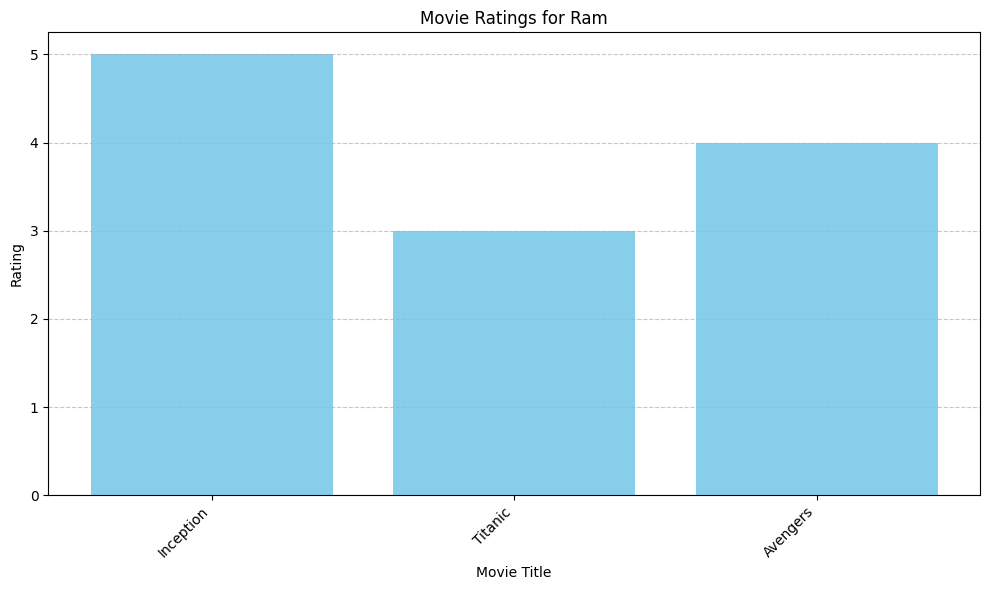

In [11]:
import matplotlib.pyplot as plt

# 1. Access the ratings for the user 'Ram'
user_ratings = users["Ram"]

# 2. Extract movie titles and their corresponding ratings
movie_titles = list(user_ratings.keys())
ratings = list(user_ratings.values())

# 3. Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(movie_titles, ratings, color='skyblue')

# 4. Set the x-axis label
plt.xlabel('Movie Title')

# 5. Set the y-axis label
plt.ylabel('Rating')

# 6. Add a title to the chart
plt.title(f'Movie Ratings for Ram')

# Ensure all x-axis labels are visible
plt.xticks(rotation=45, ha='right')

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

user_list = []
movie_list = []
rating_list = []

for user, user_ratings in users.items():
    for movie, rating in user_ratings.items():
        user_list.append(user)
        movie_list.append(movie)
        rating_list.append(rating)

ratings_df = pd.DataFrame({
    'user': user_list,
    'movie': movie_list,
    'rating': rating_list
})

print(ratings_df.head())

  user      movie  rating
0  Ram  Inception       5
1  Ram    Titanic       3
2  Ram   Avengers       4
3  Raj  Inception       5
4  Raj    Titanic       1


In [17]:
from sklearn.model_selection import train_test_split

# Split the ratings_df into training and testing sets
train_df, test_df = train_test_split(ratings_df, test_size=0.25, random_state=42)

# Print the shapes of the training and testing sets
print(f"Shape of training data: {train_df.shape}")
print(f"Shape of testing data: {test_df.shape}")

Shape of training data: (6, 3)
Shape of testing data: (2, 3)


In [18]:
import collections

# Convert train_df to a dictionary format suitable for the recommend function
train_users = collections.defaultdict(dict)
for index, row in train_df.iterrows():
    train_users[row['user']][row['movie']] = row['rating']

# Adapt the similarity function to use the new train_users dictionary
def similarity_adapted(user1_data, user2_data):
    common = set(user1_data.keys()) & set(user2_data.keys())

    if not common:
        return 0

    score = 0
    for item in common:
        score += 5 - abs(user1_data[item] - user2_data[item])

    return score

# Adapt the recommend function to use the new train_users dictionary
def recommend_adapted(user_name, all_users_data):
    target = all_users_data[user_name]
    scores = {}

    for other in all_users_data:
        if other == user_name:
            continue

        sim = similarity_adapted(target, all_users_data[other])

        for item in all_users_data[other]:
            if item not in target:
                scores[item] = scores.get(item, 0) + sim

    # Sort recommendations by score and return movie titles
    sorted_recommendations = sorted(scores.items(), key=lambda item: item[1], reverse=True)
    return [item[0] for item in sorted_recommendations]

# Example: Generate recommendations for 'Ram' using the training data
if 'Ram' in train_users:
    ram_recommendations = recommend_adapted('Ram', train_users)
    print(f"Recommendations for Ram based on training data: {ram_recommendations}")
else:
    print("'Ram' not in training data for recommendations.")

# Also print the adapted train_users dictionary to verify its structure
print("\nStructure of train_users dictionary:")
for user, movies in train_users.items():
    print(f"{user}: {movies}")

Recommendations for Ram based on training data: ['Titanic', 'Notebook']

Structure of train_users dictionary:
Ram: {'Inception': 5, 'Avengers': 4}
Rani: {'Notebook': 4, 'Titanic': 5}
Raj: {'Titanic': 1, 'Inception': 5}


In [19]:
test_users_actual = collections.defaultdict(list)
for index, row in test_df.iterrows():
    test_users_actual[row['user']].append(row['movie'])

total_test_items = 0
hits = 0

# Evaluate for each user present in the test set and also in the training set
for user, actual_movies in test_users_actual.items():
    if user in train_users: # Ensure the user is known from training data
        # Generate recommendations for the user based on training data
        recommendations = recommend_adapted(user, train_users)

        # Count how many actual test movies were recommended
        for movie in actual_movies:
            total_test_items += 1
            if movie in recommendations:
                hits += 1

# Calculate hit rate
if total_test_items > 0:
    hit_rate = hits / total_test_items
    print(f"Total actual test items: {total_test_items}")
    print(f"Hits: {hits}")
    print(f"Model Hit Rate on Test Set: {hit_rate:.2f}")
else:
    print("No test items to evaluate.")

Total actual test items: 2
Hits: 2
Model Hit Rate on Test Set: 1.00
